In [1]:
# 파이썬 라이브러리 및 모듈 가져오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

In [2]:
np.random.seed(2025)
satisfaction = np.random.normal(7.5, 1.5, 1000)
satisfaction = np.clip(satisfaction, 1, 10)
df1 = pd.DataFrame({'score': satisfaction})

# 기본 통계량
mean_val = df1['score'].mean()
median_val = df1['score'].median()
std_val = df1['score'].std()

# 연속형 데이터의 최빈값 (그대로 구하면 큰 의미 없음 → 소수 첫째 자리로 반올림 후 계산 추천)
mode_raw = df1['score'].mode()          # 원본 값 최빈값 (클리핑 값이 나올 수 있음)
mode_rounded = df1['score'].round(1).mode()  # 반올림 후 최빈값

print(f"평균     : {mean_val:.4f}")
print(f"중앙값   : {median_val:.4f}")
print(f"표준편차 : {std_val:.4f}")
print(f"최빈값(원본, 클리핑 영향 있음) : {mode_raw.tolist()}")
print(f"최빈값(소수 1자리 반올림)      : {mode_rounded.tolist()}")

평균     : 7.4287
중앙값   : 7.4217
표준편차 : 1.3927
최빈값(원본, 클리핑 영향 있음) : [10.0]
최빈값(소수 1자리 반올림)      : [10.0]


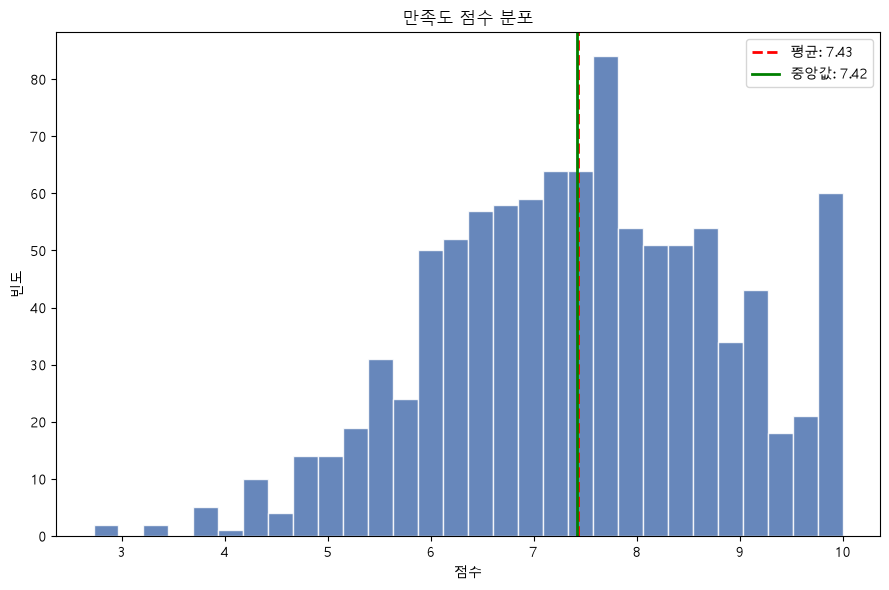

In [3]:

mean_val = df1['score'].mean()
median_val = df1['score'].median()

plt.figure(figsize=(9, 6))
plt.hist(df1['score'], bins=30, color='#4C72B0', edgecolor='white', alpha=0.85)
plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'평균: {mean_val:.2f}')
plt.axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'중앙값: {median_val:.2f}')

plt.title('만족도 점수 분포')
plt.xlabel('점수')
plt.ylabel('빈도')
plt.legend()
plt.tight_layout()
plt.show()


### 평균과 중앙값 사이의 차이는 어느 정도인가요?
  - 차이가 거의 없이 균일하다

### 두 값이 비슷하다면, 이 데이터는 어떤 분포 형태일 가능성이 있을까요? (예: 대칭형, 정규분포 등)
  - 평균과 중앙값의 차이가 거의 없다면 대칭형 그래프에 가깝다

### 두 값의 차이가 크다면, 그 이유는 무엇일까요?
  - 분포가 한쪽으로 치우쳐져있음을 시사한다

### 어떤 값들이 평균을 끌어내리거나 끌어올렸을까요?
  - 이상치들이 평균을 보정했을 가능성이 높다

### 최빈값이 평균보다 낮은 경우, 낮은 점수를 준 고객이 많다는 뜻일 수 있습니다. 이 경우 데이터 분포는 어느 쪽으로 치우쳐 있을까요?
  - 왼쪽으로 치우쳐져 있다

### 반대로 최빈값이 평균보다 높은 경우에는 어떤 해석이 가능할까요? 이럴 때 분포가 어떻게 달라질 수 있을까요?
  - 최빈값이 평균을 끌어올렸을 가능성이 높고 오른쪽으로 치우쳐진 분포가 관찰된다

### 이 데이터를 바탕으로 고객 만족도를 높이기 위한 마케팅 전략에는 어떤 것들이 있을까요?
  - 현재 10점을 준 고객들이 상위권에 위치하기 때문에 8~9점대 리뷰들을 잘 분석해서 다음 제품에 도입시킨다면 더 긍정적인 효과를 기대할 수 있다

In [4]:
np.random.seed(2025)

# A 지역: 평균 300, 표준편차 50
region_a = np.random.normal(300, 50, 100)

# B 지역: 일반 소득자 + 극단적인 고소득자 포함
region_b = np.concatenate([
    np.random.normal(280, 40, 95),    # 일반 소득자 95명
    np.random.normal(1500, 200, 5)    # 고소득자 5명
])

df2 = pd.DataFrame({
    'region': ['A'] * 100 + ['B'] * 100,
    'salary': np.concatenate([region_a, region_b])
})
# 지역별 평균 / 중앙값 / 표준편차
result = df2.groupby('region')['salary'].agg(['mean', 'median', 'std'])
print(result)

              mean      median         std
region                                    
A       292.506637  294.324483   46.520667
B       347.594909  287.347488  290.417556


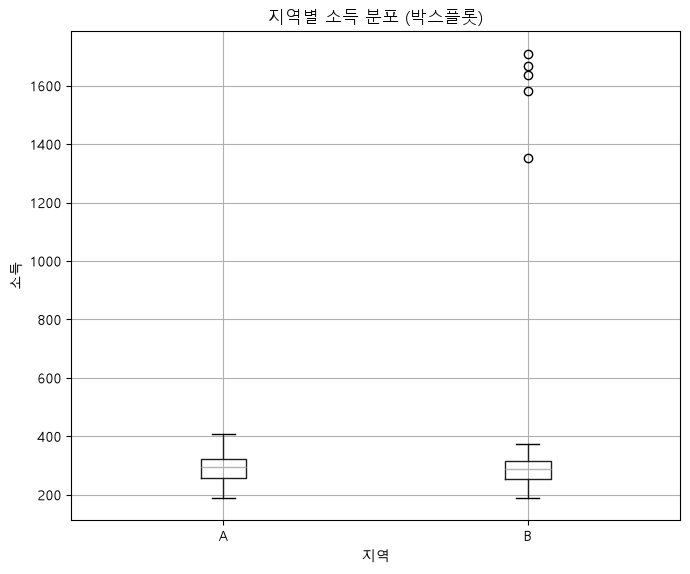

In [5]:
df2 = pd.DataFrame({
    'region': ['A'] * 100 + ['B'] * 100,
    'salary': np.concatenate([region_a, region_b])
})

fig, ax = plt.subplots(figsize=(7, 6))
df2.boxplot(column='salary', by='region', ax=ax)
ax.set_title('지역별 소득 분포 (박스플롯)')
ax.set_xlabel('지역')
ax.set_ylabel('소득')
plt.suptitle('')  # boxplot이 자동으로 붙이는 상단 제목 제거
plt.tight_layout()
plt.show()

### A 지역과 B 지역의 평균 연봉은 어떻게 다른가요?
  - B지역의 평균연봉이 훨씬 높게 나왔다
### 두 지역의 평균 차이가 의미하는 바는 무엇인가요?
  - B지역에 고소득자가 있다
### 고소득자가 있는 지역의 평균은 어떤 영향을 받을까요?
  - 소수의 고소득자가 지역 평균을 크게 끌어올린다
### 중앙값은 어떠한가요?
  - 중앙값은 오히려 A가 더 높다
### 평균과 비교했을 때, 중앙값이 더 낮거나 높다면 어떤 해석이 가능할까요?
  - 중앙값보다 평균이 높다면 이상치의 값들이 평균을 끌어올린게 아닌지 확인해볼 필요가 있다
### 극단값(고소득자)의 영향은 어디에서 더 크게 나타날까요?
  - 평균이 중앙값보다 이상치에 더 민감하다
### 평균과 중앙값 중 어떤 지표가 극단값에 더 민감한가요?
  - 중앙값
### 박스플롯을 통해 어떤 점을 관찰할 수 있나요?
  - 두 지역모두 사분위, 최대 최소, 중앙값 모두 비슷한 수준이지만 B지역에서 극단값의 분포를 확인할 수 있다
### 이상치(Outlier)는 어떻게 표시되나요?
  - 동그란 원
### 두 지역의 분포 폭(사분위 범위)은 어떻게 다른가요?
  - 사분위 범위는 거의 비슷해서 눈으로 구별하기 쉽지않다 - 하지만 B지역의 표준편차가 294로 엄청난 극단값이 있음을 보여준다
### 평균만 보고 판단했을 때 생길 수 있는 오해는 무엇인가요?
  - 극단값 하나에도 평균은 크게 영향을 받기 때문에 분포를 먼저 확인해보고 평균을 쓸지 중앙값을 쓸지 구분해야한다
### 어떤 경우에는 중앙값이 더 유용한 지표일 수 있을까요?
  - 분포가 치우쳐져 있을때(대부분의 현실세계) 중앙값이 더 유용한 지표이다

In [6]:
import numpy as np
import pandas as pd

np.random.seed(2025)
class1 = np.random.normal(75, 8, 30)
class2 = np.concatenate([
    np.random.normal(75, 15, 28),
    [0, 130]
])
df3 = pd.DataFrame({
    'class': ['1반'] * 30 + ['2반'] * 30,
    'score': np.concatenate([class1, class2])
})

# 반별 평균 / 표준편차 / 최솟값 / 최댓값
result = df3.groupby('class')['score'].agg(['mean', 'std', 'min', 'max'])
print(result)

            mean        std        min         max
class                                             
1반     75.724316   7.062710  60.685416   92.175893
2반     73.728848  22.340818   0.000000  130.000000


### 어떤 반의 점수 분산이 더 크고, 왜 그럴까요?
  - 2반의 분산이 더 크다 왜냐하면 2반에는 이상치가 있기 때문이다
### 점수 분포의 퍼짐 정도는 어떤 지표로 확인할 수 있을까요?
  - 표준편차로 확인할 수 있음
### 이상값이 포함되면 표준편차나 범위는 어떻게 달라질까요?
  - 이상값이 포함되면 표준편차가 매우 커진다 = 이상치에 민감하다
### 이상값이 있는 반의 평균은 어떤 영향을 받았나요?
  - 이상치가 0과 130으로 평균 자체로는 크게 변한게 없어보인다
### 극단적으로 낮거나 높은 점수가 평균을 끌어내리거나 끌어올렸나요?
  - 그렇다
### 평균과 중앙값의 차이가 의미하는 바는 무엇인가요?
  - 중앙값은 이상치에 영향을 거의 받지 않는다 
### 평균만 보고 평가했을 때 생길 수 있는 오해는 무엇인가요?
  - 두 반의 평균이 비슷하다고 착각할 수 있다
### 중앙값이나 표준편차 같은 지표와 함께 분석하는 것은 왜 중요할까요?
  - 표준편차는 이상치에 굉장히 민감하고 중앙값이나 IQR은 영향을 받지 않는다 따라서 같이 사용하면 좀 더 정확한 분석을
  할 수 있다

In [11]:
# class별 Q1, Q3를 원본 행 개수 그대로 매핑
Q1 = df3.groupby('class')['score'].transform(lambda s: s.quantile(0.25))
Q3 = df3.groupby('class')['score'].transform(lambda s: s.quantile(0.75))
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df3_clean = df3[(df3['score'] >= lower) & (df3['score'] <= upper)]

print("제거 전:")
print(df3.groupby('class')['score'].agg(['count', 'mean', 'std', 'min', 'max']))
print("\n제거 후:")
print(df3_clean.groupby('class')['score'].agg(['count', 'mean', 'std', 'min', 'max']))

제거 전:
       count       mean        std        min         max
class                                                    
1반        30  75.724316   7.062710  60.685416   92.175893
2반        30  73.728848  22.340818   0.000000  130.000000

제거 후:
       count       mean        std        min         max
class                                                    
1반        28  75.673863   5.930711  63.488944   87.711812
2반        28  74.352338  14.733411  54.101464  103.523111


### 이상값 제거 전후 평균은 어떻게 달라졌나요?
  - 이상치를 제거하자 2반의 평균이 살짝 올라갔다
### 평균이 중앙값에 가까워졌나요?
  - 그렇다
### 이상값 제거가 평균에 어떤 방향으로 영향을 주었나요?
  - 원래 0과 130이었는데 아무래도 분포가 50점 이상에 많이 분포하다보니 0이 사라지고 오히려 평균이 올라갔다
### 왜 IQR을 기준으로 이상값을 판단할까요?
  - IQR은 데이터의 가운데 50%기준으로 얼마나 퍼져있는지를 보기 때문에 이상치에 영향을 거의 받지 않기 때문이다
### IQR은 데이터를 어떻게 나누고, 어떤 방식으로 이상값을 정의하나요?
  - 하위 = Q1 - 1.5*(Q3-Q1), 상위 = Q3 + 1.5(Q3-Q1)은 중간폭 50%의 1.5배를 벗어난 값은 이상치로 본다 라는 뜻이다
### 평균이나 표준편차 기준과 비교했을 때 어떤 점이 더 강건할까요?
  - 평균이나 표준편차 모두 이상치에 매우 취약하다
### 이상값은 언제 제거하고, 언제 유지해야 할까요?
  - 보통의 경우 제거를 하는것이 맞지만 주의해야 한다 왜냐면 정말로 실제 의미가 있는 값일수도 있기 때문이다
### 분석 목적에 따라 이상값은 중요한 정보가 될 수 있습니다.

### 중앙값과 평균은 각각 어떤 상황에서 더 유용한 지표인가요?
  - 평균은 전체적인 그림이나 좀 더 대중적인 지표이고 중앙값은 분포가 치우쳐진 데이터에서 많이 활용된다
### 이상값이 있을 때 어떤 지표가 더 신뢰할 수 있나요?
  - 중앙값
### 두 지표를 함께 보면 어떤 장점이 있을까요?
  - 이상치의 여부도 확인할 수 있고 데이터의 분포 또한 확인할 수 있다

In [13]:
np.random.seed(2025)
df5 = pd.DataFrame({
    'age': np.random.randint(18, 65, 200),
    'coffee_type': np.random.choice(['아메리카노', '라떼', '카페모카'], 200),
    'size': np.random.choice(['Small', 'Medium', 'Large'], 200),
    'price': np.random.normal(4500, 500, 200),
    'satisfaction': np.random.randint(1, 6, 200)
})
df5.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   age           200 non-null    int32  
 1   coffee_type   200 non-null    str    
 2   size          200 non-null    str    
 3   price         200 non-null    float64
 4   satisfaction  200 non-null    int32  
dtypes: float64(1), int32(2), str(2)
memory usage: 9.6 KB


### 숫자처럼 보이지만 사실은 범주형 또는 서열형으로 해석하는 변수가 있다면 무엇일까요?
  - 만족도
### 변수 유형에 따라 적절한 분석 방법이나 시각화 방식은 어떻게 달라질까요?
  - 수치형은 상관없지만 범주형은 적절한 인코딩 방법을 사용해서 바꿔주어야한다

              temp  humidity     sales
temp      1.000000 -0.115936  0.906593
humidity -0.115936  1.000000 -0.390105
sales     0.906593 -0.390105  1.000000


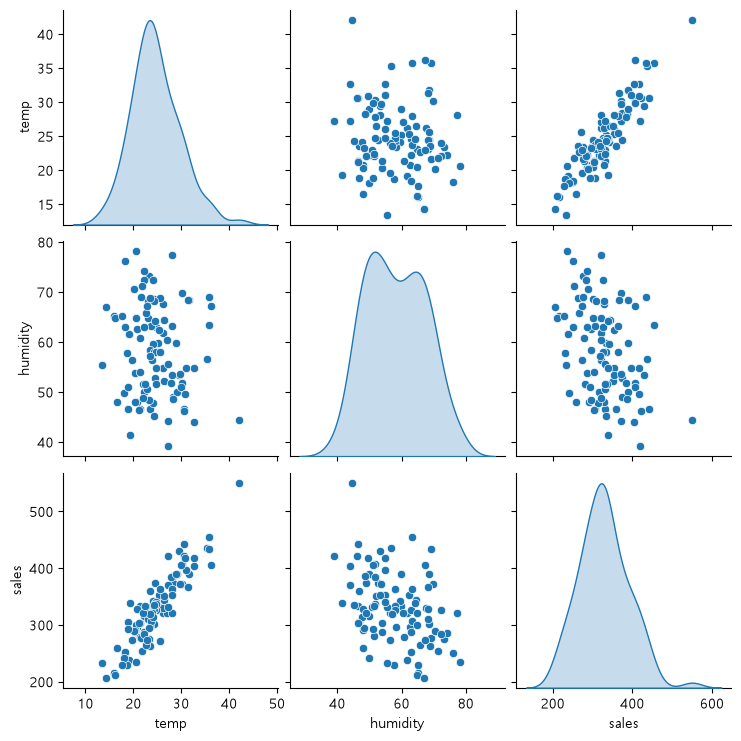

In [14]:
np.random.seed(202)
temp = np.random.normal(25, 5, 100)
humidity = np.random.normal(60, 10, 100)
sales = temp * 10 - humidity * 2 + np.random.normal(0, 20, 100) + 200
df6 = pd.DataFrame({'temp': temp, 'humidity': humidity, 'sales': sales})

# 상관계수 행렬 (숫자로 확인)
print(df6.corr())

# pairplot으로 시각화
sns.pairplot(df6, diag_kind='kde')
plt.show()

### 어떤 변수와 sales 간의 상관계수가 가장 높은가요?
  - 온도
### 어느 쌍이 양의 상관관계, 어느 쌍이 음의 상관관계인가요?
  - 온도와 매출이 강한 양의 상관관계를 가지고 매출과 습도가 약한 음의 상관관계를 가진다
### 어떤 변수 쌍은 직선 형태로 관계가 보이나요?
  - 온도와 매출
### 어떤 변수 쌍은 분산이 크거나 패턴이 없는가요?
  - 온도와 매출을 제외하면 사실상 패턴이 없음
### 온도와 매출에 상관관계가 있다고 해서, 온도가 매출을 직접적으로 증가시킨다고 볼 수 있을까요?
  - 상관관계는 인과관계를 뜻하지 않는다. 그냥 온도가 상승할때 매출도 상승했다는것만 뜻한다
### 이 데이터를 바탕으로 어떤 추가 가설이나 실험 설계를 생각해볼 수 있을까요?
  - 온도와 매출의 인과관계를 파악할 수 있는 다른 추가적은 변수들이 더 있어야만 진짜 인과관계가 있는지 아니면 다른 이유가 있었는지 알 수 있다
  예를들어 어떤 품목의 매출을 가지고 온건지, 또 어느 지역에 대한 매출인지, 그 지역의 온도와 습도는 어땠는지 등
  스피어만 상관관계는 비선형 관계도 잡아낼 수 있어 사용을 고려해볼수도 있다.
  피어슨 상관관계는 선형 관계만 잡기 때문이다.

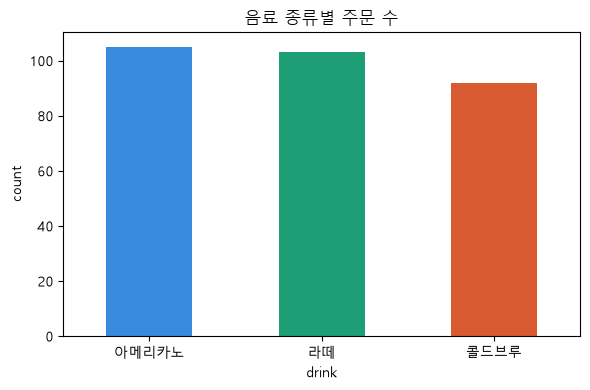

In [15]:
np.random.seed(202)
df7 = pd.DataFrame({
    'drink': np.random.choice(['아메리카노', '라떼', '콜드브루'], 300)
})

# 한글 폰트 설정 (윈도우면 '맑은 고딕'으로 바로 됨)
plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows 기준
plt.rcParams['axes.unicode_minus'] = False

counts = df7['drink'].value_counts()

plt.figure(figsize=(6,4))
counts.plot(kind='bar', color=['#378ADD', '#1D9E75', '#D85A30'])
plt.title('음료 종류별 주문 수')
plt.xlabel('drink')
plt.ylabel('count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 판매량이 가장 많은 음료는?
  - 아메리카노
### 그 다음으로 인기 있는 음료는?
  - 라떼
### 이 결과는 어떤 마케팅 전략에 활용할 수 있을까요?
  - 아메리카노와 라떼는 이미 인기메뉴이므로 콜드브루에 대한 추가적인 할인이나 프로모션으로 매출 증가를 노려볼 수 있다
### 막대그래프는 왜 범주형 변수에 적합할까요?
  - 카테고리별로 수치를 표현하기에 좋고 라인그래프와 같이 청중들이 직관적으로 알아보기 쉽다
### drink처럼 종류가 명확히 나뉘는 변수를 분석할 때 어떤 점이 중요한가요?
  - 인코딩을 잘 선택해야 하며 수치 연산을 하면 안된다 또한 유사한 범주끼리 묶어줘야 과적합이 발생하지 않는다
### 범주형 변수 분석 시 주의할 점은?
  - 공백, 표기 오류 등 문자열 오염 여부를 신경써서 확인해야 한다
  순서형인지 명목형인지 확인해야 한다 순서형인데 one hot encoding을 써버리면 서열이 사라지므로 ordinal encoding이 적절하다
  또한 명복형인데 라벨인코딩을 해버리면 순서를 따지는 알고리즘에서 잘못 학습해버릴수도 있다
  고유값이 너무 많은경우 칼럼이 폭발적증가 해버린다(타겟 인코딩이 방법)
  결측값을 하나의 범주라고 착각하면 안된다

In [16]:
df8 = pd.DataFrame({
    'day': np.random.choice(['월', '화', '수', '목', '금', '토', '일'], 500),
    'amount': np.random.normal(12000, 2000, 500)
})
result = df8.groupby('day')['amount'].agg(['mean'])
print(result)

             mean
day              
금    12440.705395
목    11802.291256
수    12129.460899
월    11742.721702
일    11957.771395
토    12162.741734
화    12083.529063


day
월    11742.721702
화    12083.529063
수    12129.460899
목    11802.291256
금    12440.705395
토    12162.741734
일    11957.771395
Name: amount, dtype: float64


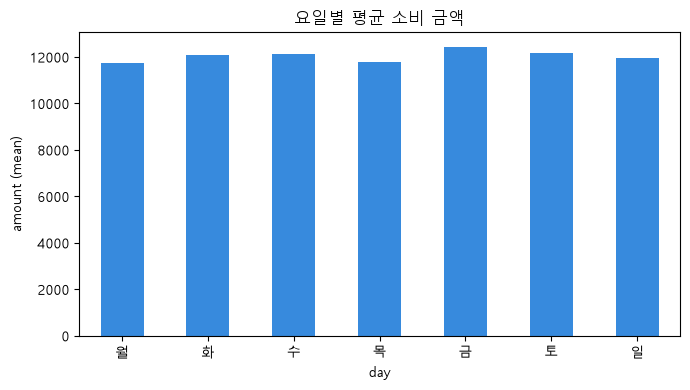

In [18]:
order = ['월', '화', '수', '목', '금', '토', '일']
result = df8.groupby('day')['amount'].mean().reindex(order)
print(result)

plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(7,4))
result.plot(kind='bar', color='#378ADD')
plt.title('요일별 평균 소비 금액')
plt.xlabel('day')
plt.ylabel('amount (mean)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [21]:
from scipy import stats
weekend_days = ['토', '일']
df8['day_type'] = df8['day'].apply(lambda x: '주말' if x in weekend_days else '평일')

# 2. 그룹별 평균 비교
result = df8.groupby('day_type')['amount'].agg(['mean', 'std', 'count']).round(2)
print(result)

# 3. 이 차이가 통계적으로 의미 있는지 t-검정으로 확인
weekday_amt = df8[df8['day_type'] == '평일']['amount']
weekend_amt = df8[df8['day_type'] == '주말']['amount']
t_stat, p_value = stats.ttest_ind(weekday_amt, weekend_amt)
print(f"t-statistic: {t_stat:.3f}, p-value: {p_value:.3f}")

              mean      std  count
day_type                          
주말        12066.06  1946.81    159
평일        12013.45  2078.58    341
t-statistic: -0.269, p-value: 0.788


### 어떤 요일에 소비 금액이 가장 높나요?
  - 금요일
### 주말(토, 일)과 평일(월~금) 중 어떤 쪽의 평균이 더 높은가요?
  - 주말 하지만 거의 차이 없음
### 소비 금액이 적은 요일은 언제인가요? 왜 그럴까요?
  - 목요일, 정확한 이유는 알 수 없지만 카페의 위치, 주변 상권, 공휴일 등 여러가지 다른 요인들을 체크하면 알 수 있다고 생각한다
### 이 결과를 어떻게 활용할 수 있을까요?
  - 주말에 더 많은 재고를 준비할 필요는 없을 것 같다 데이터로만 보면 주말과 평일의 차이가 거의 없기 때문에 
  오히려 손실이 날수도 있다 대신 메뉴별 매출량을 비교해서 상대적 비인기 메뉴들의 할인을 진행하던가
  프로모션을 진행하면 긍정적인 효과를 기대할 수 있다

In [22]:
np.random.seed(2025)

# 1. 평균 70, 표준편차 10인 정규분포 데이터 1000개 생성
mean, std = 70, 10
data = np.random.normal(mean, std, 1000)

print(f"실제 평균: {data.mean():.3f}")
print(f"실제 표준편차: {data.std():.3f}")

# 2. ±1σ, ±2σ 범위 비율 계산
within_1sigma = ((data >= mean - 1*std) & (data <= mean + 1*std)).mean() * 100
within_2sigma = ((data >= mean - 2*std) & (data <= mean + 2*std)).mean() * 100
within_3sigma = ((data >= mean - 3*std) & (data <= mean + 3*std)).mean() * 100

print(f"±1σ (60~80) 범위 비율: {within_1sigma:.2f}%")
print(f"±2σ (50~90) 범위 비율: {within_2sigma:.2f}%")
print(f"±3σ (40~100) 범위 비율: {within_3sigma:.2f}%")

# 3. 68-95-99.7 법칙과 비교
print(f"±1σ: 이론 68%   vs 실제 {within_1sigma:.2f}%")
print(f"±2σ: 이론 95%   vs 실제 {within_2sigma:.2f}%")
print(f"±3σ: 이론 99.7% vs 실제 {within_3sigma:.2f}%")

실제 평균: 69.685
실제 표준편차: 9.621
±1σ (60~80) 범위 비율: 70.50%
±2σ (50~90) 범위 비율: 96.00%
±3σ (40~100) 범위 비율: 99.80%
±1σ: 이론 68%   vs 실제 70.50%
±2σ: 이론 95%   vs 실제 96.00%
±3σ: 이론 99.7% vs 실제 99.80%


### ±1σ, ±2σ 범위에 실제로 몇 %의 데이터가 포함되었나요?
  - ±1σ: 이론 68%   vs 실제 70.50%
    ±2σ: 이론 95%   vs 실제 96.00%
    ±3σ: 이론 99.7% vs 실제 99.80%
### 이 결과는 68–95–99 법칙과 얼마나 비슷했나요?
  - 거의 비슷했다
### 표준편차는 왜 중요한 지표인가요?
  - 평균만으로는 알 수 없는 데이터를 알려준다. 예를들어 평균이 같더라도 분포는 다를 수 있기 때문에 표준편차로 알 수가 있다
  또한 이를 통해 "예측"을 할 수가 있다 표준편차가 작으면 분포가 모여있으므로 예측을 하는데 용이하다, 반대로 표준편차가 크면 예측이 어렵다
  이상치의 판단 기준도 될 수 있다
### 이 개념이 실제로 어떻게 활용될 수 있을까요?
  - 이상치 탐지에 사용할 수 있다
  신뢰구간을 설정 할 수 있다(신뢰구간?)
  성과/등급을 메길수 있다
  다만 정확히 정규분포를 따를 때에만 사용할 수 있다

표본크기 5  → 평균: 99.919, 표준편차: 6.669
표본크기 50 → 평균: 99.931, 표준편차: 2.143


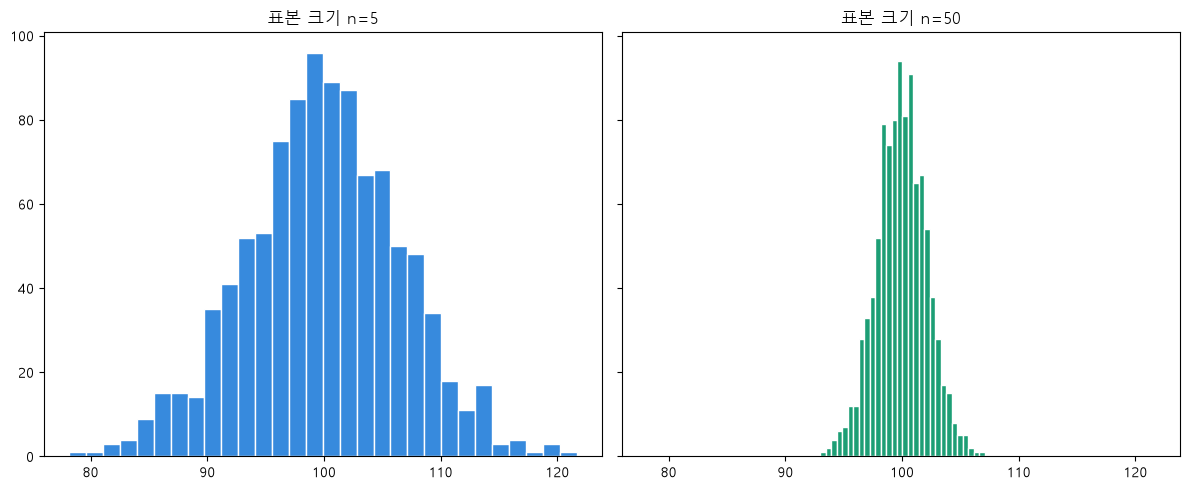

In [23]:
np.random.seed(2025)

# 1. 모집단: 평균 100, 표준편차 15
pop_mean, pop_std = 100, 15
population = np.random.normal(pop_mean, pop_std, 100000)

# 2. 표본 크기 5, 50에서 각각 1000번 표본 평균 구하기
n_trials = 1000
sample_means_5 = [np.random.choice(population, size=5, replace=False).mean() for _ in range(n_trials)]
sample_means_50 = [np.random.choice(population, size=50, replace=False).mean() for _ in range(n_trials)]

sample_means_5 = np.array(sample_means_5)
sample_means_50 = np.array(sample_means_50)

print(f"표본크기 5  → 평균: {sample_means_5.mean():.3f}, 표준편차: {sample_means_5.std():.3f}")
print(f"표본크기 50 → 평균: {sample_means_50.mean():.3f}, 표준편차: {sample_means_50.std():.3f}")

# 3. 히스토그램 비교
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
axes[0].hist(sample_means_5, bins=30, color='#378ADD', edgecolor='white')
axes[0].set_title('표본 크기 n=5')
axes[1].hist(sample_means_50, bins=30, color='#1D9E75', edgecolor='white')
axes[1].set_title('표본 크기 n=50')
plt.tight_layout()
plt.show()

### 표본 크기가 다를 때 표본 평균 분포는 어떻게 달라졌나요?
  - 표본크기가 커질수록 표준편차가 작아졌음
### 왜 표본 크기가 중요할까요?
  - 표본크기가 커질수록 (n>=30) 모양이 정규분포에 근사한다 이때 원래 모집단분포의 모양과는 아무상관이 없다
### 이 개념은 실제로 어디에 활용될 수 있을까요?
  - 데이터(모집단)의 분포를 몰라도, 표본 평균은 정규분포를 따른다는 걸 알기 때문에 신뢰구간, 가설검정(t-검정, z-검정) 같은 도구를 쓸 수 있다
  다만 표본은 독립적, 무작위로 추출되어야함
  보통 n을 30이상으로 잡지만 극심한 불균형이면 더 크게 잡아야할 수도 있음

기울기(계수): 7.909
절편: 51.606
R²: 0.927


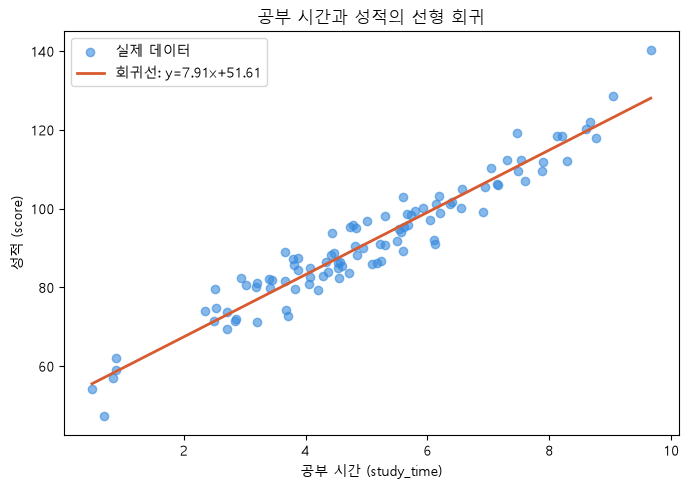

In [24]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

np.random.seed(505)
study_time = np.random.normal(5, 2, 100)
score = 50 + study_time * 8 + np.random.normal(0, 5, 100)
df11 = pd.DataFrame({'study_time': study_time, 'score': score})

# 1. 단순 선형 회귀모델 학습
X = df11[['study_time']]
y = df11['score']

model = LinearRegression()
model.fit(X, y)

# 2. 기울기와 절편 출력
slope = model.coef_[0]
intercept = model.intercept_
r_squared = model.score(X, y)

print(f"기울기(계수): {slope:.3f}")
print(f"절편: {intercept:.3f}")
print(f"R²: {r_squared:.3f}")

# 3. 산점도 + 회귀선 시각화
plt.figure(figsize=(7, 5))
plt.scatter(df11['study_time'], df11['score'], alpha=0.6, color='#378ADD', label='실제 데이터')

x_line = np.linspace(df11['study_time'].min(), df11['study_time'].max(), 100)
y_line = model.predict(x_line.reshape(-1, 1))
plt.plot(x_line, y_line, color='#D85A30', linewidth=2, label=f'회귀선: y={slope:.2f}x+{intercept:.2f}')

plt.title('공부 시간과 성적의 선형 회귀')
plt.xlabel('공부 시간 (study_time)')
plt.ylabel('성적 (score)')
plt.legend()
plt.tight_layout()
plt.show()

### 공부 시간이 성적에 어떤 영향을 주었나요?
  - 공부 1시간 늘어날때마다 성적이 7.9점 늘었다(기울기) 절편:51.606은 공부0시간일때의 성적을 뜻한다
  결정계수 R*2은 study_time하나만으로 성적 변동의 92.7%를 설명할 수 있다는 뜻이다
### 회귀선은 데이터를 잘 설명하고 있나요?
  - 이 데이터 한정으로는 잘 설명하고 있다
### 이 회귀식을 현실에 적용할 수 있을까요?
  - 불가능
  현실은 단순 두개의 변수만으로는 설명되지 않음 또한 관계가 무한히 선형적일 수 없음
### 선형 회귀분석은 언제 활용할 수 있을까요?
  - 탐색적 분석(대략보기) 초기 단계에서 관계가 있다 없다 정도를 확인할 수 있음 - 대략적인 예측

In [29]:
!pip install statsmodels -q

In [28]:
import numpy as np
from statsmodels.stats.proportion import proportions_ztest

np.random.seed(606)
group_a = np.random.binomial(1, 0.12, 1000)
group_b = np.random.binomial(1, 0.15, 1000)

# 1. 각 그룹의 전환율 계산
conv_a = group_a.mean()
conv_b = group_b.mean()

n_a, n_b = len(group_a), len(group_b)
success_a, success_b = group_a.sum(), group_b.sum()

print(f"A 그룹: 전환 {success_a}명 / 전체 {n_a}명 → 전환율 {conv_a*100:.2f}%")
print(f"B 그룹: 전환 {success_b}명 / 전체 {n_b}명 → 전환율 {conv_b*100:.2f}%")
print(f"전환율 차이 (B - A): {(conv_b - conv_a)*100:.2f}%p")

# 2. 두 비율 z-검정으로 유의성 확인
count = np.array([success_a, success_b])
nobs = np.array([n_a, n_b])
z_stat, p_value = proportions_ztest(count, nobs)

print(f"z-statistic: {z_stat:.3f}")
print(f"p-value: {p_value:.4f}")

A 그룹: 전환 131명 / 전체 1000명 → 전환율 13.10%
B 그룹: 전환 133명 / 전체 1000명 → 전환율 13.30%
전환율 차이 (B - A): 0.20%p
z-statistic: -0.132
p-value: 0.8949


### 두 그룹의 전환율 차이는 얼마나 되나요?
  - 0.20%
### 차이가 '의미 있다'는 건 무엇을 뜻하나요?
  - : p-value가 크다고 두 그룹이 진짜로 같다는 증거는 아님. 표본이 부족해서 못 잡아낸 것일 수도 있음
### 이 실험 결과로 어떤 결정을 내릴 수 있을까요?
  - A/B 테스트를 시작하기 전에 "이 정도 효과 크기를 탐지하려면 최소 몇 명이 필요한가"를 미리 계산
### A/B 테스트는 현실에서 어떻게 쓰일까요?